## Middleware

- Middleware provides a way to more tightly control inside the agent. Middleware is useful for the following use cases:
    - Tracking agent behavior with logging, and debugging.
    - Transforming prompts. tool selection, and output formatting.
    - Adding retries, fallbacks, and early terminating logic.
    - Applying rate limit, guardrails, and other Pll detection logic.

In [29]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

## Summarization Middleware

- Automatically summarize the conversation history when appoaching token limit, preserving recent messages while compressing older context. Summarization is useful for the following:
    - Long-running conversations that exceed context window.
    - multi-turn dialogues with extensive history.
    - Application where preserving full conversation context matters.

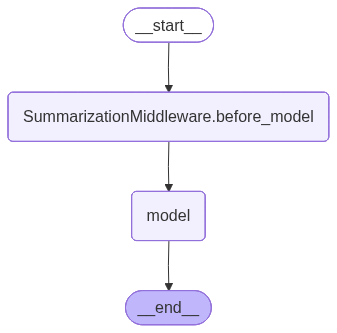

In [30]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver

# Agent with messagebased summarization
agent = create_agent(
    model = 'groq:qwen/qwen3-32b',
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model= 'groq:qwen/qwen3-32b',
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)

agent

In [31]:
# Thread id
config = {
    "configurable": {
        "thread_id": "test1"
    }
}

In [32]:
# Alternate test data
from langchain.messages import HumanMessage


questions = [
    "What is the capital of France?",
    "Who wrote 'To Kill a Mockingbird'?",
    "What is the largest planet in our solar system?",
    "What is the boiling point of water?",
    "Who painted the Mona Lisa?",
    "What is the currency of Japan?",
    "What is the tallest mountain in the world?",
    "Who discovered penicillin?",
    "What is the speed of light?",
    "What is the chemical symbol for gold?"
]

for q in questions:
    response = agent.invoke({
        "messages": [
            HumanMessage(content=q)
        ]
    }, config)
    print(f"Messages:{response}")
    print(f"Messages: {len(response['messages'])}")

Messages:{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='c32a2ec6-39a4-4bde-90c8-c7ec0adcb60b'), AIMessage(content='<think>\nOkay, so the question is asking for the capital of France. Let me think. I remember from school that France is a country in Europe, and its capital is... Paris? Yeah, I think that\'s right. But wait, maybe I should double-check. Sometimes countries have names that are similar, or maybe I\'m confusing it with another country. For example, Spain\'s capital is Madrid, Italy\'s is Rome, Germany\'s is Berlin. So France should be Paris. I\'ve also heard about the Eiffel Tower in Paris, which I believe is a famous landmark there. Also, Paris is known as the city of lights. Yeah, that rings a bell. I don\'t think there\'s any other major city in France that\'s commonly mistaken for the capital. Maybe Marseille or Lyon? But no, those are big cities too, but I\'m pretty sure Paris is the capital. Let me t

### Token Size

In [33]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens"""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 start, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, bussiness center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent = create_agent(
    model = 'groq:qwen/qwen3-32b',
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model= 'groq:qwen/qwen3-32b',
            trigger=("tokens", 550),
            keep=("tokens", 200)
        )
    ]
)

config = {
    "configurable": {
        "thread_id": "test-1"
    }
}

# Token counte (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # Approximate token count (assuming 4 characters per token)


In [34]:
# Run Test
cities = ['Paris', 'London', 'Tokyo', 'New York', 'Dubai', 'singapore']

for city in cities:
    response = agent.invoke({
        "messages": [
            HumanMessage(content=f"Search hotels in {city}")
        ]
    }, config)

    token = count_tokens(response['messages'])
    print(f"{city}: ~{token} tokens, {len(response['messages'])} messages")
    print(f"Messages: {response['messages']}")

Paris: ~122 tokens, 4 messages
Messages: [HumanMessage(content='Search hotels in Paris', additional_kwargs={}, response_metadata={}, id='878a1ab1-6501-4b03-9c61-10495b436b7a'), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user wants to search for hotels in Paris. Let me check the available tools. There\'s a function called search_hotels that takes a city parameter. The city here is Paris. I need to make sure the function is called correctly with the city name. Since the function is designed to return a long response, I should execute it with the city parameter set to Paris. No other parameters are required, so the arguments should just include "city": "Paris". Let me structure the tool call accordingly.\n', 'tool_calls': [{'id': '0vawr0z39', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 128, 'prompt_tokens': 155, 'total_tokens': 283, 'completion_time': 0.

### Fraction

In [35]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens"""
    return f"""Hotels in {city}: Grand Hotel - 5 start, $350/night, spa, pool, gym"""

agent = create_agent(
    model = 'groq:qwen/qwen3-32b',
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model= 'groq:qwen/qwen3-32b',
            trigger=("fraction", 0.005),
            keep=("fraction", 0.004)
        )
    ]
)

config = {
    "configurable": {
        "thread_id": "test-1"
    }
}

# Token counte (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # Approximate token count (assuming 4 characters per token)

# Test
cities = ['Paris', 'London', 'Tokyo', 'New York', 'Dubai', 'singapore']

for city in cities:
    response = agent.invoke({
        "messages": [
            HumanMessage(content=f"Search hotels in {city}")
        ]
    }, config)

    token = count_tokens(response['messages'])
    fraction = token / 32768  # Assuming a max token limit of 32,768
    print(f"{city}: ~{token} tokens (~{fraction:.4%} of max), {len(response['messages'])} messages")
    print(f"Messages: {response['messages']}")

Paris: ~65 tokens (~0.1984% of max), 4 messages
Messages: [HumanMessage(content='Search hotels in Paris', additional_kwargs={}, response_metadata={}, id='a2194dbe-30c2-49cd-9cc5-d0f298c5d635'), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user wants to search for hotels in Paris. Let me check the available tools. There\'s a function called search_hotels that takes a city parameter. The city here is Paris. I need to make sure the function is called correctly. The parameters require a city string, so I\'ll input "Paris" as the city value. I\'ll structure the tool call with the function name and the city argument. That should retrieve the hotel information they need.\n', 'tool_calls': [{'id': 'h949ev16h', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 155, 'total_tokens': 273, 'completion_time': 0.212336191, 'completion_tokens_details': 

### Human In the Loop Middleware

- Pause agent execution for human approval, editing, or rejection of tol calls before they execute. Human-in-the-loop is useful for the following:
    - High-stakes operations requiring human approval(e.g. database writes, financial transactions).
    - Compliance workflow where human overdight is required.
    - Long-running conversations where human intervention is needed to correct or guide the agent's behavior.

In [36]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Simulate reading an email by returning a long response"""
    return f"""Email {email_id}: This is a simulated email content. It contains a lot of information that will be used to test the summarization middleware. The purpose of this email is to provide enough content to trigger the summarization process in the agent's middleware. The content of this email is intentionally verbose and detailed, including various topics, discussions, and points that are relevant to the context of the email. The goal is to ensure that the summarization middleware can effectively condense this information into a more manageable format for the agent to process and respond to. This email serves as a test case for evaluating the performance and effectiveness of the summarization middleware in handling large amounts of text data."""

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Simulate sending an email by returning a confirmation message"""
    return f"Email sent to {recipient} with subject '{subject}' and body '{body}'"

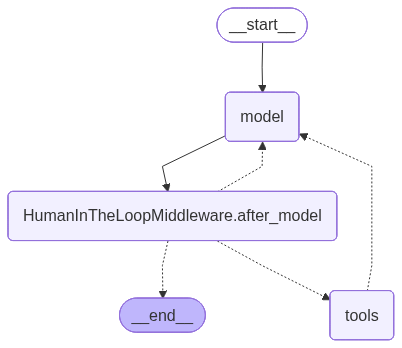

In [37]:
from langchain.agents.middleware import HumanInTheLoopMiddleware

agent = create_agent(
    model='groq:qwen/qwen3-32b',
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        )
    ],
)
agent

In [38]:
config = {
    "configurable": {
        "thread_id": "test-approve"
    }
}

result = agent.invoke({
    "messages": [
        HumanMessage(content="Send email to john@example.com with subject 'Hello' and body 'How are you?'")
    ]
}, config)

result

{'messages': [HumanMessage(content="Send email to john@example.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='2581ba9b-d525-4b90-ba0d-e5dbfd28d30b'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@example.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's the send_email_tool which requires recipient, subject, and body. All three are provided here, so I need to call that function with these parameters. No need for the read_email_tool since the request is about sending, not reading. I'll structure the tool_call with the send_email_tool and the given arguments.\n", 'tool_calls': [{'id': 'pepfjwatt', 'function': {'arguments': '{"body":"How are you?","recipient":"john@example.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 141, 'prompt_tokens': 256,

In [39]:
from langgraph.types import Command

# Step 1: Approve

if "__interrupt__" in result:
    print('Approving')

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "approve"
                    }
                ]
            }
        ),
        config=config
    )

    print(f"Result: {result['messages'][-1].content}")

Approving
Result: The email has been successfully sent to john@example.com with the subject "Hello" and the body "How are you?". Let me know if you need further assistance!


### Reject

In [40]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Simulate reading an email by returning a long response"""
    return f"""Email {email_id}: This is a simulated email content. It contains a lot of information that will be used to test the summarization middleware. The purpose of this email is to provide enough content to trigger the summarization process in the agent's middleware. The content of this email is intentionally verbose and detailed, including various topics, discussions, and points that are relevant to the context of the email. The goal is to ensure that the summarization middleware can effectively condense this information into a more manageable format for the agent to process and respond to. This email serves as a test case for evaluating the performance and effectiveness of the summarization middleware in handling large amounts of text data."""

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Simulate sending an email by returning a confirmation message"""
    return f"Email sent to {recipient} with subject '{subject}' and body '{body}'"

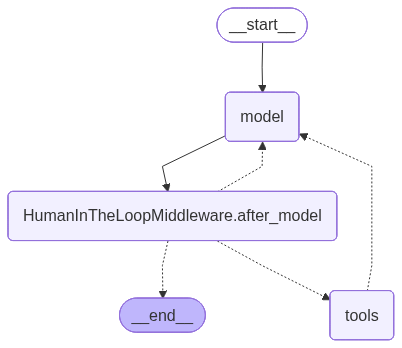

In [41]:
from langchain.agents.middleware import HumanInTheLoopMiddleware

agent = create_agent(
    model='groq:qwen/qwen3-32b',
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        )
    ],
)
agent

In [42]:
config = {
    "configurable": {
        "thread_id": "test-approve"
    }
}

result = agent.invoke({
    "messages": [
        HumanMessage(content="Send email to john@example.com with subject 'Hello' and body 'How are you?'")
    ]
}, config)

result

{'messages': [HumanMessage(content="Send email to john@example.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='8d9a143a-6c10-488c-bb58-6bc225b75aa6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@example.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's the send_email_tool which requires recipient, subject, and body. All three are required. The parameters match what the user provided. So I need to call send_email_tool with those arguments. No need to use the read_email_tool here since the task is about sending, not reading. Just structure the JSON with the correct parameters. Make sure the email ID isn't needed here. Yep, the send function doesn't require an email_id. Alright, that's all.\n", 'tool_calls': [{'id': 'w5nsy5j22', 'function': {'arguments': '{"body":"How are you?","recipient":"john@example.com","subject":"Hello"}'

In [43]:
# Step 2: Reject
if "__interrupt__" in result:
    print('Rejecting')

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "reject"
                    }
                ]
            }
        ),
        config=config
    )

    print(f"Result: {result['messages'][-1].content}")

Rejecting
Result: It seems the email could not be sent at this time. The system has rejected the tool call with ID `w5nsy5j22`, and instructions indicate not to retry unless you explicitly request it. Would you like me to attempt sending the email again, or is there another action you'd prefer?


### Editing

In [44]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Simulate reading an email by returning a long response"""
    return f"""Email {email_id}: This is a simulated email content. It contains a lot of information that will be used to test the summarization middleware. The purpose of this email is to provide enough content to trigger the summarization process in the agent's middleware. The content of this email is intentionally verbose and detailed, including various topics, discussions, and points that are relevant to the context of the email. The goal is to ensure that the summarization middleware can effectively condense this information into a more manageable format for the agent to process and respond to. This email serves as a test case for evaluating the performance and effectiveness of the summarization middleware in handling large amounts of text data."""

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Simulate sending an email by returning a confirmation message"""
    return f"Email sent to {recipient} with subject '{subject}' and body '{body}'"

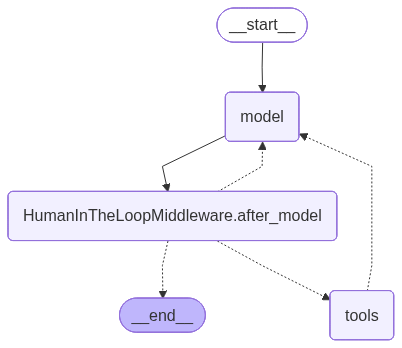

In [45]:
from langchain.agents.middleware import HumanInTheLoopMiddleware

agent = create_agent(
    model='groq:qwen/qwen3-32b',
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        )
    ],
)
agent

In [46]:
config = {
    "configurable": {
        "thread_id": "test-approve"
    }
}

result = agent.invoke({
    "messages": [
        HumanMessage(content="Send email to john@example.com with subject 'Hello' and body 'How are you?'")
    ]
}, config)

result

{'messages': [HumanMessage(content="Send email to john@example.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='df29af60-9ae9-401e-b190-c15b9ad26c0f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@example.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's the send_email_tool which requires recipient, subject, and body. All three are required. The parameters match what the user provided. So I need to call send_email_tool with those arguments. No need for the read_email_tool here since the request is about sending, not reading. Let me structure the tool call correctly. The arguments should be a JSON object with recipient, subject, and body. Double-check the email address and the message to make sure there are no typos. Everything looks good. Ready to return the tool call.\n", 'tool_calls': [{'id': 'cjx74cpgh', 'function': {'argum

In [47]:
# Step 3: Edit
if "__interrupt__" in result:
    print('Editing')

    # Primary format (uses "edited_action")
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",
                            "args": {
                                "recipient": "corrected@example.com",
                                "subject": "Corrected Subject",
                                "body": "Corrected body content."
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )

    print(f"Result: {result['messages'][-1].content}")
    

Editing
Result: The email was not sent as intended due to an error in processing your request. My tool response incorrectly altered the recipient, subject, and body. Let me fix this:

1. **Recipient:** Changed from `john@example.com` to `corrected@example.com` (this was an error)
2. **Subject:** Changed from `"Hello"` to `"Corrected Subject"` (this was an error)
3. **Body:** Changed from `"How are you?"` to `"Corrected body content."` (this was an error)

Would you like me to resend the email with your original parameters?
